In [8]:
from sklearn.datasets import fetch_california_housing
import pandas as pd


data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
Y = pd.Series(data.target, name="Price")

print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
print(X.head())

print("\nOriginal Price:")
print(Y.head())

Dataset Shape: (20640, 8)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Original Price:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Missing values:", X.isnull().sum().sum())
median_price = Y.median()
print("Median Price:", median_price)


# 0 = Low price
# 1 = High price
Y_class = (Y >= median_price).astype(int)

print("\nClass distribution:")
print(Y_class.value_counts())
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_class,
    test_size=0.2,
    random_state=42,
    stratify=Y_class
)

print("\nTraining:", X_train.shape)
print("Testing :", X_test.shape)

Missing values: 0
Median Price: 1.797

Class distribution:
Price
1    10325
0    10315
Name: count, dtype: int64

Training: (16512, 8)
Testing : (4128, 8)


In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed")

Scaling completed


In [11]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, Y_train)
Y_pred_tree = tree.predict(X_test)

print("Decision Tree completed")

Decision Tree completed


In [12]:
pruned_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

pruned_tree.fit(X_train, Y_train)
Y_pred_pruned = pruned_tree.predict(X_test)

print("Pruned Decision Tree completed")

Pruned Decision Tree completed


In [13]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train_scaled, Y_train)
Y_pred_logistic = logistic.predict(X_test_scaled)

print("Logistic Regression completed")

Logistic Regression completed


In [14]:
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

lasso.fit(X_train_scaled, Y_train)
Y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso completed")

Lasso completed


In [15]:
ridge = LogisticRegression(
    penalty="l2",
    max_iter=1000
)

ridge.fit(X_train_scaled, Y_train)
Y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge completed")

Ridge completed


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def calculate_metrics(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [17]:
results = []

results.append(
    calculate_metrics(
        "Decision Tree",
        Y_test,
        Y_pred_tree
    )
)

results.append(
    calculate_metrics(
        "Pruned Decision Tree",
        Y_test,
        Y_pred_pruned
    )
)

results.append(
    calculate_metrics(
        "Logistic Regression",
        Y_test,
        Y_pred_logistic
    )
)

results.append(
    calculate_metrics(
        "Lasso",
        Y_test,
        Y_pred_lasso
    )
)

results.append(
    calculate_metrics(
        "Ridge",
        Y_test,
        Y_pred_ridge
    )
)

In [18]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(results_df)

                  Model  Accuracy  Precision    Recall  F1 Score
0         Decision Tree  0.839147   0.836941  0.842615  0.839768
1  Pruned Decision Tree  0.796027   0.818988  0.760291  0.788548
2   Logistic Regression  0.827277   0.826255  0.829056  0.827653
3                 Lasso  0.828246   0.827536  0.829540  0.828537
4                 Ridge  0.827277   0.826255  0.829056  0.827653


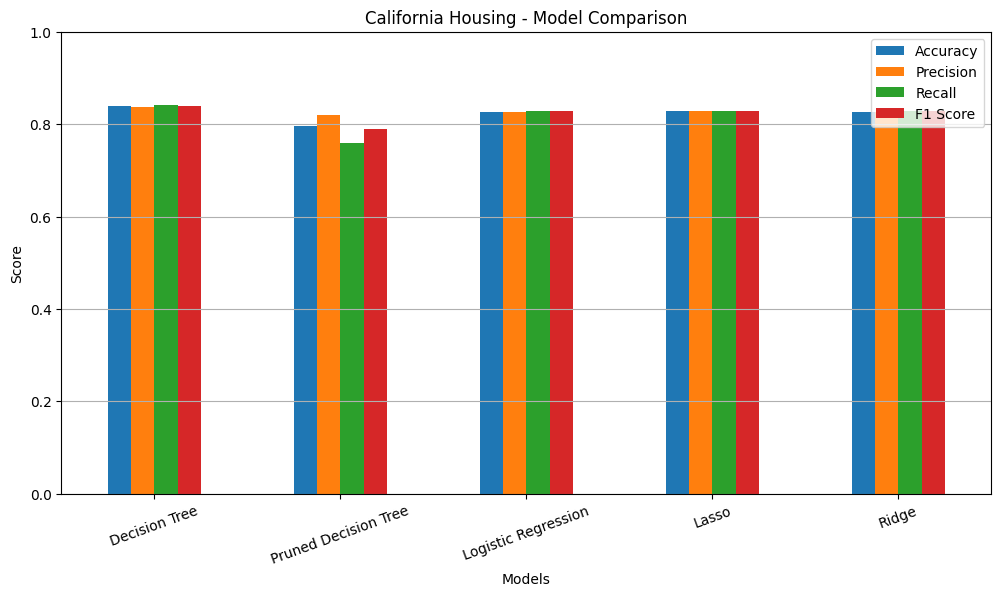

In [19]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("California Housing - Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

In [20]:
print("Lasso Coefficients:\n")

for feature, coefficient in zip(
    X.columns,
    lasso.coef_[0]
):
    print(f"{feature:15} : {coefficient:.4f}")

Lasso Coefficients:

MedInc          : 2.4718
HouseAge        : 0.2582
AveRooms        : -0.7251
AveBedrms       : 0.8536
Population      : 0.0582
AveOccup        : -2.6261
Latitude        : -3.6635
Longitude       : -3.4283


In [21]:
print("Ridge Coefficients:\n")

for feature, coefficient in zip(
    X.columns,
    ridge.coef_[0]
):
    print(f"{feature:15} : {coefficient:.4f}")

Ridge Coefficients:

MedInc          : 2.4709
HouseAge        : 0.2593
AveRooms        : -0.7328
AveBedrms       : 0.8575
Population      : 0.0571
AveOccup        : -2.5083
Latitude        : -3.6211
Longitude       : -3.3905
